In [71]:
import requests
from PIL import Image
from io import BytesIO
import numpy as np
from collections import Counter
from typing import Literal, Tuple, List
from scipy.ndimage import label
import pandas as pd
import matplotlib.pyplot as plt
from skimage.measure import regionprops

In [3]:
# pull sample data to work with
def fetch_image(url):
    # using different combination of header seems to help with the anti scrape problem
    headers_sample = [
    
    {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/17.5 Safari/605.1.15",
    "Accept": "image/avif,image/webp,image/apng,image/*,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.9"
    }
,
    {
    "User-Agent": "Mozilla/5.0 (iPhone; CPU iPhone OS 17_4 like Mac OS X) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/17.4 Mobile/15E148 Safari/604.1",
    "Accept": "image/avif,image/webp,image/apng,image/*,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.9"
    }
,
    {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:143.0) Gecko/20100101 Firefox/143.0",
    "Accept": "image/avif,image/webp,image/apng,image/*,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.9"
    }
,
    {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/17.5 Safari/605.1.15",
    }
,
    {
    "User-Agent": "Mozilla/5.0 (iPhone; CPU iPhone OS 17_4 like Mac OS X) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/17.4 Mobile/15E148 Safari/604.1",
    }
,
    {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:143.0) Gecko/20100101 Firefox/143.0",
    }
]

    for header in headers_sample :
        r = requests.get(url, timeout=15,headers=header) # try each header 
        r.raise_for_status() # new line for downstream functionality 
        return r.content




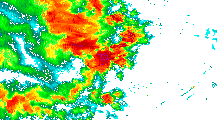

(217, 120)


In [5]:
# ts_str = '202510091010'

# url = 'https://www.nea.gov.sg/docs/default-source/rain-area/dpsri_70km_'+ts_str+'0000dBR.dpsri.png'

# res = fetch_image(url)
# with open('sample_data/test_image.jpg','wb') as f:
#     f.write(res)

with open('sample_data/test_image.jpg','rb') as f:
    data = f.read()


image_buffer = BytesIO(data)

img = Image.open(image_buffer)
display(img)

print(img.size)

In [33]:
# helpers 

# convert jpeg to RGBA 
def jpeg_to_rgba(img) :
    img_convert = img.convert('RGBA')
    rgba_array = np.array(img_convert,dtype= np.uint8)

    # decompose the channels
    rgb = rgba_array[... , :3] 
    alpha = rgba_array[... , 3]

    return rgb, alpha


legend = [
    ((  0, 255, 255),  5.0),  # cyan
    ((  0, 200, 150), 10.0),  # aqua-green
    ((  0, 255,   0), 20.0),  # green
    ((150, 255,   0), 28.0),  # yellow-green
    ((255, 255,   0), 35.0),  # yellow
    ((255, 200,   0), 42.0),  # amber
    ((255, 150,   0), 50.0),  # orange
    ((255, 100,   0), 58.0),  # red-orange
    ((255,   0,   0), 65.0),  # red
    ((255,   0, 255), 70.0),  # magenta/purple
]

def rgb_to_dbz(img) :
    img_convert = img.convert('RGBA')
    rgba_array = np.array(img_convert,dtype= np.uint8)

    # decompose the channels
    rgb = rgba_array[... , :3] 
    alpha = rgba_array[... , 3]
    H, W = rgb.shape[:2]
    mask = alpha > 0 

    # legend arrays
    legend_rgb = np.array([c for c, _ in legend], dtype=np.int16)   # (K,3)
    legend_dbz = np.array([z for _, z in legend], dtype=np.float32) # (K,)

    # 3) flatten pixels for vectorized distance calc
    flat = rgb.reshape(-1, 3) # from grid to single list of each pixel
    N, K = flat.shape[0], legend_rgb.shape[0]

    # 4) l2 distances to all legend colors (N,K)
    d2 = np.sum((flat[:, None, :] - legend_rgb[None, :, :])**2, axis=2)  # squared distances
    d  = np.sqrt(d2, dtype=np.float32)

    # 5) find top 2 closest
    nearest_two = np.argsort(d, axis=1)[:, :2]   
    i0 = nearest_two[:, 0]                      
    i1 = nearest_two[:, 1]                      

    d0 = d[np.arange(N), i0]                     
    d1 = d[np.arange(N), i1]                     
    z0 = legend_dbz[i0]                            
    z1 = legend_dbz[i1]                             


    exact = (d0 == 0.0)
    # start with zeros
    dbz_flat = np.zeros(N, dtype=np.float32)

    # 7) Inverse-distance weighting for non-exact matches
    #    dbz = (z0/d0 + z1/d1) / (1/d0 + 1/d1)
    #    Use a tiny epsilon guard in case of numerical edge cases
    eps = 1e-6
    w0 = np.where(exact, 1.0, 1.0 / np.maximum(d0, eps))
    w1 = np.where(exact, 0.0, 1.0 / np.maximum(d1, eps))
    num = w0 * z0 + w1 * z1
    den = w0 + w1
    dbz_flat = np.where(exact, z0, num / np.maximum(den, eps))

    # 8) Reshape back to image grid and apply background
    dbz_grid = dbz_flat.reshape(H, W)
    dbz_grid[~mask] = float(0)

    # 9) Round to integers (final requirement)
    return np.rint(dbz_grid).astype(int)

def binary_storm_mask(dbz_grid,threshold_dbz) : 
    mask = (dbz_grid >= threshold_dbz).astype(np.uint8)
    return mask



In [39]:
a,b = jpeg_to_rgba(img)
print(a.shape)

(120, 217, 3)


In [ ]:
test = rgb_to_dbz(img)
test

/var/folders/c9/rl6pcdvd1_xb6ng3n8l9wr2w0000gn/T/ipykernel_48030/8928490.py:48: RuntimeWarning: invalid value encountered in sqrt
  d  = np.sqrt(d2, dtype=np.float32)


array([[62, 62, 46, ...,  0,  0,  0],
       [25, 54, 62, ...,  0,  0,  0],
       [25, 25, 25, ...,  0,  0,  0],
       ...,
       [46, 46, 43, ...,  0,  0,  0],
       [54, 46, 62, ...,  0,  0,  0],
       [ 0, 54,  0, ...,  0,  0,  0]], shape=(120, 217))

In [60]:
storm_test = binary_storm_mask(test, 50)

print(storm_test.shape)
storm_test

(120, 217)


array([[1, 1, 0, ..., 0, 0, 0],
       [0, 1, 1, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [1, 0, 1, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0]], shape=(120, 217), dtype=uint8)

In [68]:
labels, num_storms = label(storm_test, structure=np.ones((3,3)))

view = pd.DataFrame(labels)
view
num_storms

325

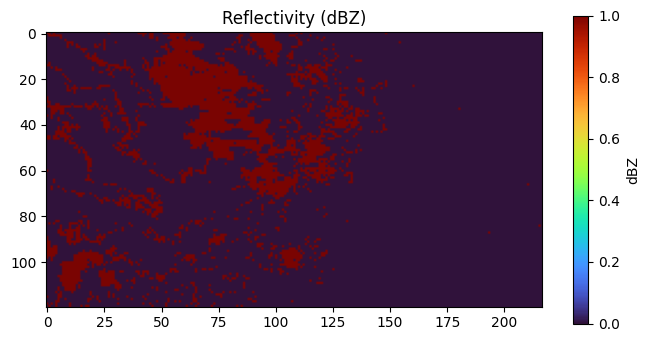

In [69]:
plt.figure(figsize=(8,4))                # control window size
plt.imshow(storm_test, cmap="turbo")       # use colourful radar-style map
plt.title("Reflectivity (dBZ)")
plt.colorbar(label="dBZ")
plt.show()

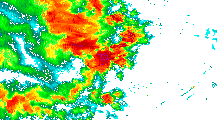

In [54]:
display(img)

In [ ]:
def filter_by_area_and_peak(storm_mask, dbz_grid,
                            min_area_px: int = 80, min_peak_dbz: float = 45.0):
    
    structure = np.ones((3,3), dtype=int)
    labels, n = label(storm_mask.astype(np.uint8), structure=structure)

    keep = np.zeros_like(labels, dtype=bool)
    for lab in range(1, n+1):
        comp = (labels == lab)
        area = int(comp.sum())
        if area < min_area_px:
            continue
        # peak dBZ within this component
        peak = float(dbz_grid[comp].max()) if area > 0 else -np.inf
        if peak >= min_peak_dbz:
            keep |= comp

    # relabel kept components
    labels_kept, n_kept = label(keep.astype(np.uint8), structure=structure)
    return labels_kept, n_kept




In [ ]:
filtered_groups , number = filter_by_area_and_peak(storm_test,test)


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(120, 217), dtype=int32)

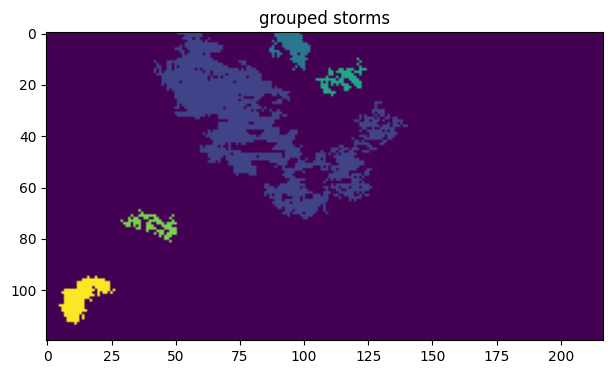

In [79]:
plt.figure(figsize=(8,4))           
plt.imshow(filtered_groups)      
plt.title("grouped storms")
plt.show()